# Phase 2: T-Learner

**Goal:** Implement the T-Learner meta-learner using LightGBM. Train separate models on the treatment and control groups, then compute individual uplift scores as the difference in predicted probabilities.

**Approach:** Manual implementation with `LGBMClassifier` to keep the mechanics transparent.

**Uplift score:** `P(visit | T=1) - P(visit | T=0)` per user

**Outputs:**
- `models/lgbm_treatment.pkl`
- `models/lgbm_control.pkl`
- `data/tlearner_scores.parquet` (uplift scores, true labels, treatment labels for Phase 4 evaluation)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import os

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Data

Load the 10% stratified sample saved from notebook 1.

In [2]:
df = pd.read_parquet("../data/df_sample.parquet")

print("Shape:", df.shape)
df.head()

Shape: (1397958, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.421336,4.679882,10.280525,4.115453,0.294443,4.833815,3.920995,22.570329,5.300375,-0.168679,0,0,0,0
1,12.616365,10.059654,8.890714,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,0,0,0,0
2,25.983277,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
3,22.584651,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
4,12.616365,10.679513,8.334491,4.679882,10.280525,3.013064,0.294443,5.863476,3.910792,24.452088,5.300375,-0.168679,0,0,0,0


## 3. Train/Test Split

Stratify by `visit` and `treatment` to preserve group proportions in both splits.

In [3]:
features = [f'f{i}' for i in range(12)]

X = df[features]
y = df['visit']
t = df['treatment']
stratify_col = y.astype('str') + '_' + t.astype('str')

In [4]:
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, 
    test_size=0.2, 
    random_state=1, 
    stratify=stratify_col
)

In [5]:
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Treatment ratio in train: {t_train.mean():.3f}")
print(f"Treatment ratio in test:  {t_test.mean():.3f}")
print(f"Visit rate in train: {y_train.mean():.4f}")
print(f"Visit rate in test:  {y_test.mean():.4f}")

Train: 1,118,366 rows | Test: 279,592 rows
Treatment ratio in train: 0.850
Treatment ratio in test:  0.850
Visit rate in train: 0.0470
Visit rate in test:  0.0470


Treatment ratio and visit rate should be nearly identical between train and test, confirming stratification worked. `t_train` and `t_test` are kept separate from `y` because the T-Learner trains on treatment and control subsets independently, and the Qini evaluation in Phase 4 requires knowing each test user's treatment label.

## 4. Train T-Learner Models

Train one `LGBMClassifier` on the treatment group and one on the control group, both predicting `visit`.

In [6]:
X_train_t = X_train[t_train == 1]
y_train_t = y_train[t_train == 1]
X_train_c = X_train[t_train == 0]
y_train_c = y_train[t_train == 0]


params = dict(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,            # default
    min_child_samples=50,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,                # use all CPU cores
    verbose=-1                # suppresses LightGBM's default per-iteration output
)

model_t = LGBMClassifier(**params)
model_c = LGBMClassifier(**params)

model_t.fit(X_train_t, y_train_t)
model_c.fit(X_train_c, y_train_c)

,learning_rate,0.05
,n_estimators,200
,min_child_samples,50
,random_state,42
,n_jobs,-1
,is_unbalance,True
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000


We train on treatment and control subsets independently. Note the size difference: treatment group is ~85% of training data, control is ~15%. Both models use identical hyperparameters so any performance difference reflects the data, not the setup.

After fitting, useful attributes:
- `model.feature_importances_`: MDI importance per feature
- `model.n_features_in_`: confirms 12 features were used
- `model.booster_`: underlying LightGBM booster for low-level access

Treatment model trained on: 950,612 rows
Control model trained on:   167,754 rows

Feature importances (number of times used to split a node across 200 trees):
     treatment  control
f2        1495     1489
f0        1052     1074
f8         924     1009
f6         861      848
f9         596      516
f3         397      313
f7         233      250
f10        220      265
f4          70      103
f11         66       49
f5          54       63
f1          32       21


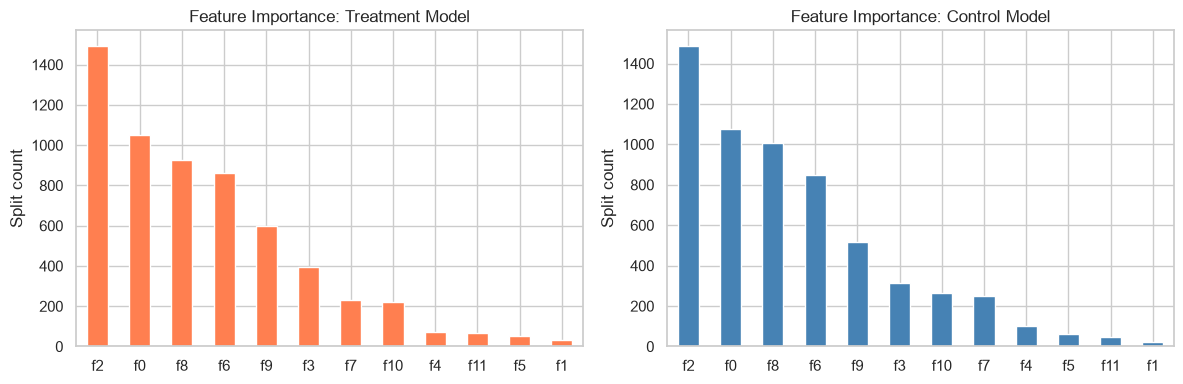

In [7]:
print(f"Treatment model trained on: {len(X_train_t):,} rows")
print(f"Control model trained on:   {len(X_train_c):,} rows")

feat_names = [f"f{i}" for i in range(12)]
imp_t = pd.Series(model_t.feature_importances_, index=feat_names)
imp_c = pd.Series(model_c.feature_importances_, index=feat_names)

imp_df = pd.DataFrame({
    "treatment": imp_t,
    "control": imp_c,
}).sort_values("treatment", ascending=False)

print("\nFeature importances (number of times used to split a node across 200 trees):")
print(imp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
imp_t.sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="coral", rot=0)
axes[0].set_title("Feature Importance: Treatment Model")
axes[0].set_ylabel("Split count")
imp_c.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="steelblue", rot=0)
axes[1].set_title("Feature Importance: Control Model")
axes[1].set_ylabel("Split count")
plt.tight_layout()
plt.show()

**Split count** is LightGBM's default importance metric: each time a tree in the ensemble needs to partition a node, it picks the feature that best reduces the loss at that split. The split count for a feature is how many times it was chosen across all nodes in all 200 trees.

The treatment and control models agree almost exactly on the ranking, which is expected since T ⊥ X ensures the two groups have the same feature distributions. Any large divergence would signal a data problem.

Comparing to the paper's Random Forest MDI ranking (f2, f8, f9, f0 as top four):
- f2 is the top feature in both, consistent with the paper
- f0 ranks higher in our models (2nd) than in the paper (4th)
- f8 ranks 3rd in our models vs 2nd in the paper
- f9 drops to 5th in our models vs 3rd in the paper
- The bottom tier (f1, f5, f4, f11) is consistently weak in both

The ordering differences are expected: our models use LightGBM (split count) while the paper uses Random Forest MDI (gain-based). The overall signal is consistent: f2 dominates, f0/f8/f9 are the next tier, and f1 is the least useful feature.

## 5. Compute Uplift Scores

For each user in the test set: `uplift = model_t.predict_proba(X_test)[:, 1] - model_c.predict_proba(X_test)[:, 1]`

In [8]:
uplift_scores = model_t.predict_proba(X_test)[:,1] - model_c.predict_proba(X_test)[:,1]
uplift_scores = pd.Series(uplift_scores, index=X_test.index, name="uplift")
print(f"Uplift scores computed for {len(uplift_scores):,} users")


Uplift scores computed for 279,592 users


In [9]:
print(uplift_scores.describe())

count    279592.000000
mean          0.015539
std           0.071774
min          -0.593192
25%          -0.003921
50%           0.003744
75%           0.019397
max           0.734798
Name: uplift, dtype: float64


Each score is the model's estimate of how much more likely a user is to visit if treated vs not treated. A score of 0.0155 means the model predicts a 1.55 percentage point incremental lift for that user. Negative scores indicate users the model thinks are slightly hurt by the ad (sleeping dogs in uplift modeling terminology).

Reading the distribution:
- Mean 0.0155: the average predicted lift across all test users, compared against the observed ATE in section 6
- Median 0.0037: most users cluster near zero, meaning the model predicts little incremental effect for the majority
- Max 0.73: a small group of users have very high predicted lift, these are the persuadables the model is identifying
- The mean being much higher than the median confirms a right-skewed distribution, which is typical in uplift modeling

## 6. Sanity Check

Compute the observed ATE directly from the test set labels and compare against the model's mean uplift score. They should be in the same order of magnitude.

In [10]:
ate_from_eda = y_test[t_test == 1].mean() - y_test[t_test == 0].mean()
print(f"ATE from test set (observed):  {ate_from_eda:.4f}")
print(f"Mean uplift score (predicted): {uplift_scores.mean():.4f}")

ATE from test set (observed):  0.0103
Mean uplift score (predicted): 0.0155


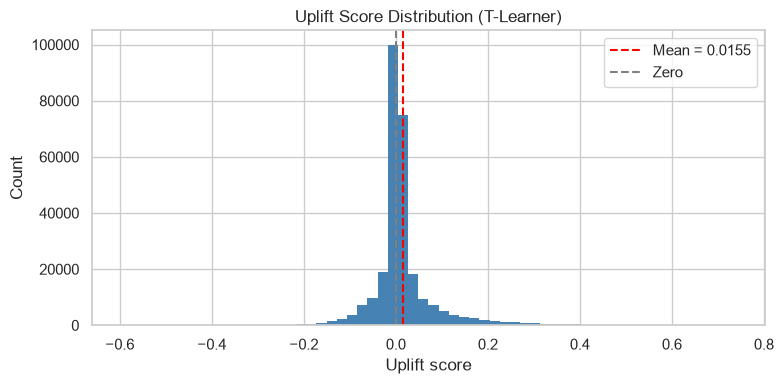

In [11]:
plt.figure(figsize=(8, 4))
uplift_scores.hist(bins=60, color="steelblue", edgecolor="none")
plt.axvline(uplift_scores.mean(), color="red", linestyle="--", label=f"Mean = {uplift_scores.mean():.4f}")
plt.axvline(0, color="gray", linestyle="--", label="Zero")
plt.title("Uplift Score Distribution (T-Learner)")
plt.xlabel("Uplift score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../images/uplift_distribution_tlearner.png", dpi=150, bbox_inches="tight")
plt.show()

The observed ATE (0.0103) is the raw difference in visit rates between treated and control users in the test set. The mean uplift score (0.0155) is the model's average prediction of that same quantity. They are in the same order of magnitude, which confirms the models are directionally correct.

The gap (0.0052) is expected. `is_unbalance=True` adjusts class weights to compensate for the low visit rate (4.7%), which shifts predicted probabilities upward and inflates the mean uplift score. Perfect calibration is not required here since we rank users by uplift score rather than using the raw values directly.

## 7. Save Models

In [12]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model_t, "../models/lgbm_treatment.pkl")
joblib.dump(model_c, "../models/lgbm_control.pkl")

df_scores = pd.DataFrame({
    "uplift": uplift_scores,
    "y_true": y_test,
    "treatment": t_test,
})
df_scores.to_parquet("../data/tlearner_scores.parquet", index=False)

print("Saved: models/lgbm_treatment.pkl")
print("Saved: models/lgbm_control.pkl")
print("Saved: data/tlearner_scores.parquet")

Saved: models/lgbm_treatment.pkl
Saved: models/lgbm_control.pkl
Saved: data/tlearner_scores.parquet


Both models and the uplift scores are now persisted. Phase 3 (X-Learner) will train its own model and produce a separate scores file in the same format. Phase 4 (Evaluation) will load both score files and compare T-Learner vs X-Learner using the Qini curve without needing to retrain anything.